# Bowtie SLSQP - is the diagonal solution a local minimum?

Companion to [02_optimization.ipynb](02_optimization.ipynb). Same 7x7 bowtie field (`dx[3,3]=+1.2, dx[3,4]=-1.2`).

**Hypothesis under test.** The full-grid SLSQP solution from `02` displaces the deformed bowtie vertices *diagonally* (it adds y-components to dy). Intuition says the cleanest fix is *horizontal-only*: just shrink the x-displacements so the two crossed pixels uncross, leaving dy untouched. This notebook checks whether SLSQP converged to a local minimum by:

1. Constructing a few **hand-crafted horizontal-only solutions** and computing their L2 cost relative to `phi0`.
2. Running a **constrained-horizontal SLSQP** (full grid free in `dx`, `dy` frozen at 0). Because this is the dy=0 subspace of the full problem, its minimum is an upper bound on a *true* horizontal-only optimum, and a lower bound on what full SLSQP must beat to claim the global optimum.
3. Comparing both against the **full-grid SLSQP** (free dx and dy) reproduced from `02`.

Decision rule:
- If full-SLSQP L2 < constrained-horizontal L2 → diagonal motion is genuinely cheaper (full SLSQP did the right thing).
- If full-SLSQP L2 > constrained-horizontal L2 → full SLSQP is stuck in a local minimum (the dy=0 subspace already does better).

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint
from scipy.sparse import csr_matrix

from dvfopt import DEFAULT_PARAMS, jacobian_det2D
from dvfopt.jacobian import triangle_sign_areas2D
from dvfopt.jacobian.triangle_sign import _triangle_areas_2d
from dvfopt.core.objective import objective_euc

THRESHOLD = DEFAULT_PARAMS['threshold']
print(f'threshold = {THRESHOLD}')

threshold = 0.01


## Bowtie test field

Same as `02_optimization.ipynb`: 7×7 grid, all-zero except `dx[3,3]=+1.2`, `dx[3,4]=-1.2`. Two folded cells (`min(T1,T2) = -0.7` on cells `(3,3)` and `(3,4)` per the 2-triangle check).

In [2]:
H = W = 7
dy0 = np.zeros((H, W))
dx0 = np.zeros((H, W))
dx0[3, 3] = +1.2
dx0[3, 4] = -1.2
phi0 = np.stack([dy0, dx0])

def report(phi, label):
    jd = np.squeeze(jacobian_det2D(phi))
    tri = triangle_sign_areas2D(phi)
    return {
        'label': label,
        'jd': jd, 'tri': tri,
        'n_tr': int((tri <= 0).sum()),
        'min_tr': float(tri.min()),
        'min_cd': float(jd.min()),
        'l2': float(np.linalg.norm(phi - phi0)),
        'max_dy': float(np.abs(phi[0]).max()),
        'max_dx_change': float(np.abs(phi[1] - phi0[1]).max()),
        'phi': phi,
    }

r0 = report(phi0, 'initial (uncorrected)')
print(f"initial: n_neg_tri={r0['n_tr']}, min_tr={r0['min_tr']:+.3f}, L2={r0['l2']:.3f}")

initial: n_neg_tri=2, min_tr=-0.700, L2=0.000


## Hand-crafted horizontal-only solutions

Three closed-form attempts that touch only `dx[3,3]` and `dx[3,4]`, leaving `dy` zero everywhere. The original deformed positions are at `x = 3 + 1.2 = 4.2` and `x = 4 + (-1.2) = 2.8`, i.e. swapped by 1.4.

- **(H1) symmetric 50% magnitude.** dx = ±0.6 — the literal "shrink the magnitude by half" reading. Each vertex still overshoots by 0.1, so the bowtie persists.
- **(H2) just-touching at the midpoint.** dx = ±0.5 — vertices meet at x=3.5. T1/T2 collapse to zero (degenerate, fails the strict-positive threshold but is the L2 boundary of the horizontal-feasible region with these two pixels alone).
- **(H3) just-feasible.** dx = ±(0.5 - ε) chosen so `min(T1, T2) ≥ THRESHOLD`. ε is solved analytically: with both pixels touched symmetrically and surrounding dx held at zero, the smallest triangle on cells (3,3) and (3,4) is `0.5 * (1 - 2*|dx|)` ⇒ for it to equal THRESHOLD, `|dx| = (1 - 2*THRESHOLD) / 2`.

In [3]:
def make_h(dx_mag):
    dy_ = np.zeros((H, W))
    dx_ = np.zeros((H, W))
    dx_[3, 3] = +dx_mag
    dx_[3, 4] = -dx_mag
    return np.stack([dy_, dx_])

phi_H1 = make_h(0.6)
phi_H2 = make_h(0.5)
eps_thr = (1.0 - 2 * THRESHOLD) / 2.0  # ≈ 0.49
phi_H3 = make_h(eps_thr)

manual_runs = [
    ('(H1) horizontal 50% magnitude (±0.6)', report(phi_H1, 'H1')),
    ('(H2) horizontal touching (±0.5)',      report(phi_H2, 'H2')),
    (f'(H3) horizontal just-feasible (±{eps_thr:.3f})', report(phi_H3, 'H3')),
]

hdr = f"{'variant':<44s}  {'neg_TR':>6s}  {'min_TR':>8s}  {'L2':>6s}"
print(hdr); print('-' * len(hdr))
print(f"{'initial':<44s}  {r0['n_tr']:>6d}  {r0['min_tr']:+8.3f}  {r0['l2']:>6.3f}")
for label, r in manual_runs:
    print(f"{label:<44s}  {r['n_tr']:>6d}  {r['min_tr']:+8.3f}  {r['l2']:>6.3f}")

variant                                       neg_TR    min_TR      L2
----------------------------------------------------------------------
initial                                            2    -0.700   0.000
(H1) horizontal 50% magnitude (±0.6)               2    -0.100   0.849
(H2) horizontal touching (±0.5)                    2    -0.000   0.990
(H3) horizontal just-feasible (±0.490)             0    +0.010   1.004


## SLSQP solvers

Two variants of the same problem:

- **Full SLSQP (S-full)** — `2*H*W` variables (`dx | dy` flattened), constraint = per-cell 2-triangle signed areas ≥ THRESHOLD. Same setup as `02_optimization.ipynb`.
- **Horizontal-only SLSQP (S-horiz)** — only `H*W` variables (`dx` flattened), `dy` frozen at the initial zero. The constraint vector is identical (the closure builds full `phi` internally), but the optimizer can only move x-components.

If S-horiz beats S-full on L2, the full-grid solver is stuck in a local minimum on this problem.

In [4]:
def _triangle_flat(dy_, dx_):
    T1, T2 = _triangle_areas_2d(dy_, dx_)
    return np.concatenate([T1.flatten(), T2.flatten()])


def run_full_slsqp(phi_init, threshold=THRESHOLD, max_iter=500):
    _, H_, W_ = phi_init.shape
    pixels = H_ * W_
    dy_init, dx_init = phi_init[0], phi_init[1]
    z0 = np.concatenate([dx_init.flatten(), dy_init.flatten()])

    def unpack(z):
        return z[pixels:].reshape(H_, W_), z[:pixels].reshape(H_, W_)

    def constr(z):
        return _triangle_flat(*unpack(z))

    t0 = time.time()
    res = minimize(
        lambda z: objective_euc(z, z0),
        z0, jac=True, method='SLSQP',
        constraints=[NonlinearConstraint(constr, lb=threshold, ub=np.inf)],
        options={'maxiter': max_iter, 'disp': False},
    )
    dy_out, dx_out = unpack(res.x)
    phi_out = np.stack([dy_out, dx_out])
    r = report(phi_out, 'S-full')
    r.update(t=time.time() - t0, nit=res.nit, success=bool(res.success),
             status=int(res.status), message=str(res.message))
    return r


def run_horiz_slsqp(phi_init, threshold=THRESHOLD, max_iter=500):
    """SLSQP with dy frozen at its initial value (zero in the bowtie case)."""
    _, H_, W_ = phi_init.shape
    pixels = H_ * W_
    dy_frozen = phi_init[0].copy()
    dx_init = phi_init[1]
    z0 = dx_init.flatten().copy()
    z0_init = z0.copy()

    def constr(z):
        dx_ = z.reshape(H_, W_)
        return _triangle_flat(dy_frozen, dx_)

    def obj(z):
        diff = z - z0_init
        return 0.5 * float(diff @ diff), diff

    t0 = time.time()
    res = minimize(
        obj, z0, jac=True, method='SLSQP',
        constraints=[NonlinearConstraint(constr, lb=threshold, ub=np.inf)],
        options={'maxiter': max_iter, 'disp': False},
    )
    dx_out = res.x.reshape(H_, W_)
    phi_out = np.stack([dy_frozen, dx_out])
    r = report(phi_out, 'S-horiz')
    r.update(t=time.time() - t0, nit=res.nit, success=bool(res.success),
             status=int(res.status), message=str(res.message))
    return r

In [5]:
r_full = run_full_slsqp(phi0)
r_horiz = run_horiz_slsqp(phi0)

slsqp_runs = [
    ('(S-full)  free dx and dy',  r_full),
    ('(S-horiz) free dx, dy=0 frozen', r_horiz),
]

hdr = f"{'variant':<44s}  {'nit':>4s}  {'time':>6s}  {'neg_TR':>6s}  {'min_TR':>8s}  {'L2':>6s}  {'max|dy|':>8s}  ok"
print(hdr); print('-' * len(hdr))
for label, r in slsqp_runs:
    print(
        f"{label:<44s}  {r['nit']:>4d}  {r['t']:>6.3f}  "
        f"{r['n_tr']:>6d}  {r['min_tr']:+8.3f}  {r['l2']:>6.3f}  "
        f"{r['max_dy']:>8.3f}  {r['success']}"
    )

variant                                        nit    time  neg_TR    min_TR      L2   max|dy|  ok
--------------------------------------------------------------------------------------------------
(S-full)  free dx and dy                         6   0.020       0    +0.010   0.853     0.345  True
(S-horiz) free dx, dy=0 frozen                   2   0.005       0    +0.010   1.004     0.000  True


## Combined comparison

All variants together, sorted by L2 (lowest first). Local-minimum verdict is computed automatically: if any *feasible* horizontal-only variant has lower L2 than full SLSQP, full SLSQP did not reach the global optimum on this problem.

In [6]:
all_rows = (
    [('initial', r0)]
    + [(label, r) for label, r in manual_runs]
    + [(label, r) for label, r in slsqp_runs]
)
all_rows_sorted = sorted(all_rows, key=lambda kv: kv[1]['l2'])

hdr = f"{'variant':<44s}  {'feasible':>8s}  {'neg_TR':>6s}  {'min_TR':>8s}  {'L2':>6s}"
print(hdr); print('-' * len(hdr))
for label, r in all_rows_sorted:
    feasible = 'yes' if r['min_tr'] >= THRESHOLD - 1e-9 else 'no'
    print(f"{label:<44s}  {feasible:>8s}  {r['n_tr']:>6d}  {r['min_tr']:+8.3f}  {r['l2']:>6.3f}")

print()
L2_full = r_full['l2']
L2_horiz = r_horiz['l2']
horiz_feasible = r_horiz['min_tr'] >= THRESHOLD - 1e-9
print(f'full-SLSQP   L2 = {L2_full:.4f}   max|dy| = {r_full["max_dy"]:.4f}')
print(f'horiz-SLSQP  L2 = {L2_horiz:.4f}   feasible = {horiz_feasible}')
if horiz_feasible and L2_horiz + 1e-6 < L2_full:
    pct = 100.0 * (L2_full - L2_horiz) / L2_full
    print(f'\n=> Full SLSQP is in a LOCAL MINIMUM. The dy=0 subspace already achieves a {pct:.1f}% lower L2.')
elif horiz_feasible and abs(L2_horiz - L2_full) <= 1e-6:
    print('\n=> Tie. Both variants reach the same L2; the diagonal y-component is not buying anything but is not costing anything either.')
else:
    pct = 100.0 * (L2_horiz - L2_full) / L2_horiz if horiz_feasible else float("nan")
    print(f'\n=> Full SLSQP is NOT stuck. The diagonal solution is genuinely cheaper than the best horizontal-only solution by {pct:.1f}% L2.')

variant                                       feasible  neg_TR    min_TR      L2
--------------------------------------------------------------------------------
initial                                             no       2    -0.700   0.000
(H1) horizontal 50% magnitude (±0.6)                no       2    -0.100   0.849
(S-full)  free dx and dy                           yes       0    +0.010   0.853
(H2) horizontal touching (±0.5)                     no       2    -0.000   0.990
(H3) horizontal just-feasible (±0.490)             yes       0    +0.010   1.004
(S-horiz) free dx, dy=0 frozen                     yes       0    +0.010   1.004

full-SLSQP   L2 = 0.8527   max|dy| = 0.3448
horiz-SLSQP  L2 = 1.0041   feasible = True

=> Full SLSQP is NOT stuck. The diagonal solution is genuinely cheaper than the best horizontal-only solution by 15.1% L2.


## Visual comparison

Per row: warped quad grid (folded cells outlined dark blue) + per-cell `min(T1, T2)` heatmap (`RdBu_r`, blue=fold). Read these alongside the L2 column above to see what each variant gives up.

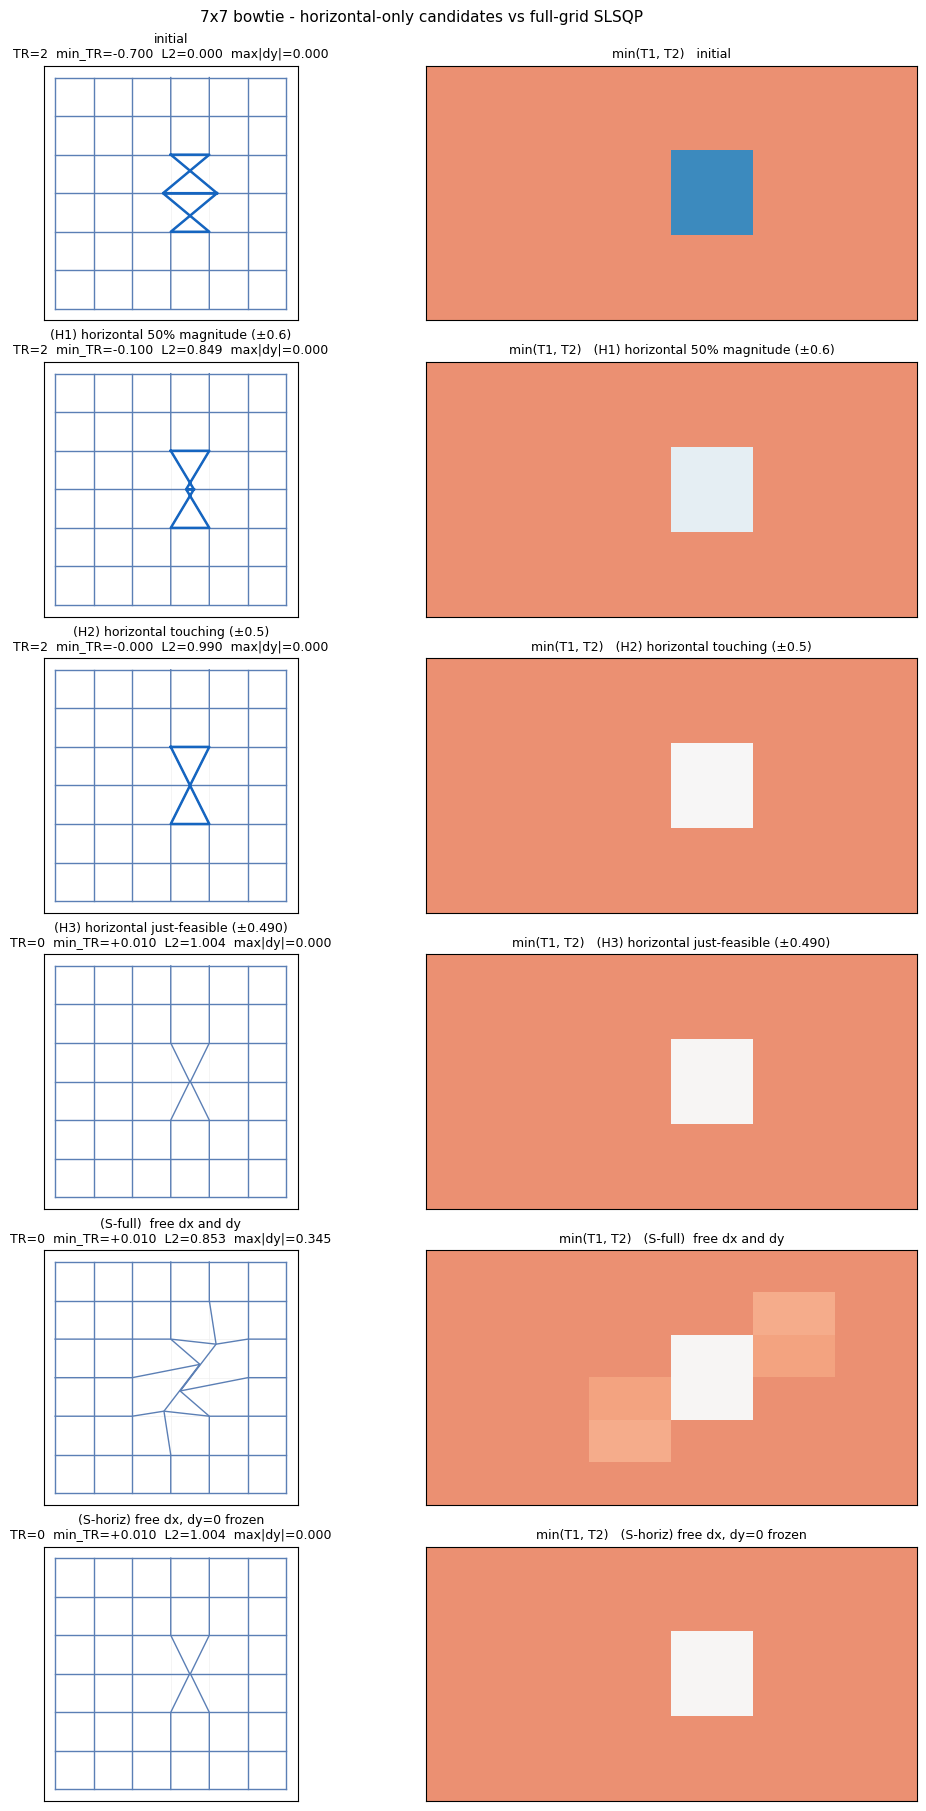

In [7]:
rows = [('initial', r0)] + [(label, r) for label, r in manual_runs] + [(label, r) for label, r in slsqp_runs]
vmax_tri = max(abs(r['tri']).max() for _, r in rows)
NL = chr(10)

def plot_warped_grid(ax, phi, title):
    dy = phi[0]; dx = phi[1]
    Hh, Ww = dy.shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + dx; gy = yy + dy
    for i in range(Hh):
        ax.plot(xx[i], yy[i], color='#f0f0f0', lw=0.5)
    for j in range(Ww):
        ax.plot(xx[:, j], yy[:, j], color='#f0f0f0', lw=0.5)
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=1.0)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=1.0)
    tri = triangle_sign_areas2D(phi)
    bad = np.argwhere(tri.min(axis=0) <= 0)
    for (cy, cx) in bad:
        px = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
        py = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
        ax.plot(px, py, color='#1565c0', lw=1.8)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(len(rows), 2, figsize=(10, 3.0 * len(rows)), layout='constrained')
for i, (label, r) in enumerate(rows):
    phi = r['phi']
    line2 = f"TR={r['n_tr']}  min_TR={r['min_tr']:+.3f}  L2={r['l2']:.3f}  max|dy|={r['max_dy']:.3f}"
    plot_warped_grid(axes[i, 0], phi, label + NL + line2)
    tri_min = r['tri'].min(axis=0)
    im = axes[i, 1].imshow(tri_min, cmap='RdBu_r', vmin=-vmax_tri, vmax=vmax_tri, aspect='auto')
    axes[i, 1].set_title(f'min(T1, T2)   {label}', fontsize=9)
    axes[i, 1].set_xticks([]); axes[i, 1].set_yticks([])

plt.suptitle('7x7 bowtie - horizontal-only candidates vs full-grid SLSQP', fontsize=11)
plt.show()

## Where does the full-SLSQP solution put its dy?

Heatmap of `dy` for the full-SLSQP solution (signed). If it is essentially zero, S-full collapsed onto the dy=0 subspace and the "diagonal" character is a numerical artifact. If it is non-trivially positive/negative, S-full genuinely paid a y-budget.

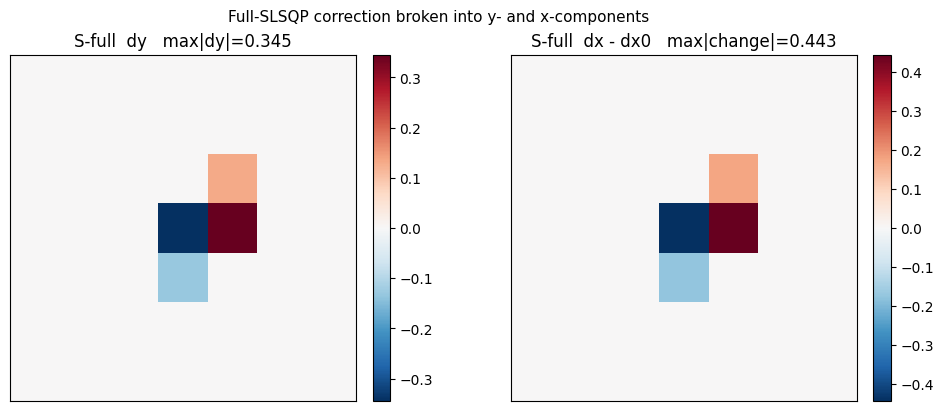

Top dy magnitudes (full-SLSQP):
  (3,3)  dy=-0.3448
  (3,4)  dy=+0.3448
  (4,3)  dy=-0.1309
  (2,4)  dy=+0.1309
  (0,0)  dy=+0.0000
  (0,1)  dy=+0.0000


In [8]:
dy_full = r_full['phi'][0]
dx_full = r_full['phi'][1]
dx_change_full = dx_full - phi0[1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')
vmax_dy = max(float(np.abs(dy_full).max()), 1e-3)
im0 = axes[0].imshow(dy_full, cmap='RdBu_r', vmin=-vmax_dy, vmax=vmax_dy)
axes[0].set_title(f'S-full  dy   max|dy|={vmax_dy:.3f}')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

vmax_dx = max(float(np.abs(dx_change_full).max()), 1e-3)
im1 = axes[1].imshow(dx_change_full, cmap='RdBu_r', vmin=-vmax_dx, vmax=vmax_dx)
axes[1].set_title(f'S-full  dx - dx0   max|change|={vmax_dx:.3f}')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Full-SLSQP correction broken into y- and x-components', fontsize=11)
plt.show()

print('Top dy magnitudes (full-SLSQP):')
flat = np.argsort(-np.abs(dy_full).ravel())[:6]
for idx in flat:
    y, x = np.unravel_index(idx, dy_full.shape)
    print(f'  ({y},{x})  dy={dy_full[y,x]:+.4f}')

## Does the same logic apply under L1?

The L2 result depends on the objective being **quadratic**: `cost = Σ Δᵢ²` strictly rewards spreading a fixed total magnitude across more variables (`T²/k` vs `T²`). Replace it with **L1** — `cost = Σ |Δᵢ|` — and that reward vanishes: distributing a fixed total over `k` variables costs the same as concentrating it. L1 actively *prefers* sparse solutions when the constraint set has corners that admit them.

Below we re-solve the constrained bowtie problem with a smoothed L1 objective `Σ √(Δᵢ² + ε²)` (`ε = 1e-4`) for both subspaces (`S-full-L1`, `S-horiz-L1`), then score every variant we have so far against the L1 metric.

In [9]:
def run_full_slsqp_l1(phi_init, threshold=THRESHOLD, max_iter=500, eps=1e-4):
    _, H_, W_ = phi_init.shape
    pixels = H_ * W_
    dy_init, dx_init = phi_init[0], phi_init[1]
    z0 = np.concatenate([dx_init.flatten(), dy_init.flatten()])

    def unpack(z):
        return z[pixels:].reshape(H_, W_), z[:pixels].reshape(H_, W_)

    def constr(z):
        return _triangle_flat(*unpack(z))

    def obj(z):
        diff = z - z0
        s = np.sqrt(diff * diff + eps * eps)
        return float(s.sum()), diff / s

    t0 = time.time()
    res = minimize(
        obj, z0.copy(), jac=True, method='SLSQP',
        constraints=[NonlinearConstraint(constr, lb=threshold, ub=np.inf)],
        options={'maxiter': max_iter, 'ftol': 1e-9, 'disp': False},
    )
    dy_out, dx_out = unpack(res.x)
    phi_out = np.stack([dy_out, dx_out])
    r = report(phi_out, 'S-full-L1')
    r.update(t=time.time() - t0, nit=res.nit, success=bool(res.success),
             status=int(res.status), message=str(res.message))
    return r


def run_horiz_slsqp_l1(phi_init, threshold=THRESHOLD, max_iter=500, eps=1e-4):
    _, H_, W_ = phi_init.shape
    pixels = H_ * W_
    dy_frozen = phi_init[0].copy()
    dx_init = phi_init[1]
    z0 = dx_init.flatten().copy()

    def constr(z):
        return _triangle_flat(dy_frozen, z.reshape(H_, W_))

    def obj(z):
        diff = z - z0
        s = np.sqrt(diff * diff + eps * eps)
        return float(s.sum()), diff / s

    t0 = time.time()
    res = minimize(
        obj, z0.copy(), jac=True, method='SLSQP',
        constraints=[NonlinearConstraint(constr, lb=threshold, ub=np.inf)],
        options={'maxiter': max_iter, 'ftol': 1e-9, 'disp': False},
    )
    dx_out = res.x.reshape(H_, W_)
    phi_out = np.stack([dy_frozen, dx_out])
    r = report(phi_out, 'S-horiz-L1')
    r.update(t=time.time() - t0, nit=res.nit, success=bool(res.success),
             status=int(res.status), message=str(res.message))
    return r


r_full_l1  = run_full_slsqp_l1(phi0)
r_horiz_l1 = run_horiz_slsqp_l1(phi0)

for tag, r in [('S-full-L1', r_full_l1), ('S-horiz-L1', r_horiz_l1)]:
    print(
        f'{tag:<12s}  nit={r["nit"]:>3d}  ok={r["success"]}  '
        f'min_TR={r["min_tr"]:+.3f}  L2={r["l2"]:.3f}  max|dy|={r["max_dy"]:.3f}  '
        f'time={r["t"]:.3f}s'
    )

S-full-L1     nit=259  ok=True  min_TR=+0.010  L2=1.004  max|dy|=0.000  time=0.792s
S-horiz-L1    nit=  3  ok=True  min_TR=+0.010  L2=1.004  max|dy|=0.000  time=0.006s


In [10]:
def l1_norm(phi):
    return float(np.abs(phi - phi0).sum())

l1_runs = (
    [('initial', r0)]
    + [(label, r) for label, r in manual_runs]
    + [(label, r) for label, r in slsqp_runs]
    + [
        ('(S-full-L1)  free dx/dy, L1 objective',  r_full_l1),
        ('(S-horiz-L1) free dx, dy=0, L1 objective', r_horiz_l1),
    ]
)
l1_runs_sorted = sorted(l1_runs, key=lambda kv: l1_norm(kv[1]['phi']))

hdr = f"{'variant':<44s}  {'feasible':>8s}  {'L1':>6s}  {'L2':>6s}  {'min_TR':>8s}"
print(hdr); print('-' * len(hdr))
for label, r in l1_runs_sorted:
    feasible = 'yes' if r['min_tr'] >= THRESHOLD - 1e-9 else 'no'
    print(f"{label:<44s}  {feasible:>8s}  {l1_norm(r['phi']):>6.3f}  {r['l2']:>6.3f}  {r['min_tr']:+8.3f}")

print()
print(f'L1 of S-full   (L2-optimal diagonal):    {l1_norm(r_full["phi"]):.4f}')
print(f'L1 of S-horiz  (L2-optimal horizontal):  {l1_norm(r_horiz["phi"]):.4f}')
print(f'L1 of S-full-L1  (L1-optimal full):      {l1_norm(r_full_l1["phi"]):.4f}')
print(f'L1 of S-horiz-L1 (L1-optimal horizontal):{l1_norm(r_horiz_l1["phi"]):.4f}')

L1_full_l1  = l1_norm(r_full_l1['phi'])
L1_horiz_l1 = l1_norm(r_horiz_l1['phi'])
print()
if L1_full_l1 + 1e-3 < L1_horiz_l1:
    pct = 100.0 * (L1_horiz_l1 - L1_full_l1) / L1_horiz_l1
    print(f'=> Under L1, the diagonal solution is still cheaper by {pct:.1f}% — the geometric tilt buys L1 too.')
elif abs(L1_full_l1 - L1_horiz_l1) <= 1e-3:
    print('=> Under L1, the full and horizontal-only optima TIE — the dy=0 subspace is no longer suboptimal.')
else:
    pct = 100.0 * (L1_full_l1 - L1_horiz_l1) / L1_full_l1
    print(f'=> Under L1, the horizontal-only subspace BEATS the full space by {pct:.1f}% (probably an SLSQP local-minimum on the full L1 problem; the L1 minimum is achievable in the dy=0 corner).')

variant                                       feasible      L1      L2    min_TR
--------------------------------------------------------------------------------
initial                                             no   0.000   0.000    -0.700
(H1) horizontal 50% magnitude (±0.6)                no   1.200   0.849    -0.100
(H2) horizontal touching (±0.5)                     no   1.400   0.990    -0.000
(H3) horizontal just-feasible (±0.490)             yes   1.420   1.004    +0.010
(S-horiz) free dx, dy=0 frozen                     yes   1.420   1.004    +0.010
(S-horiz-L1) free dx, dy=0, L1 objective           yes   1.420   1.004    +0.010
(S-full-L1)  free dx/dy, L1 objective              yes   1.420   1.004    +0.010
(S-full)  free dx and dy                           yes   2.190   0.853    +0.010

L1 of S-full   (L2-optimal diagonal):    2.1899
L1 of S-horiz  (L2-optimal horizontal):  1.4200
L1 of S-full-L1  (L1-optimal full):      1.4201
L1 of S-horiz-L1 (L1-optimal horizontal):1.42

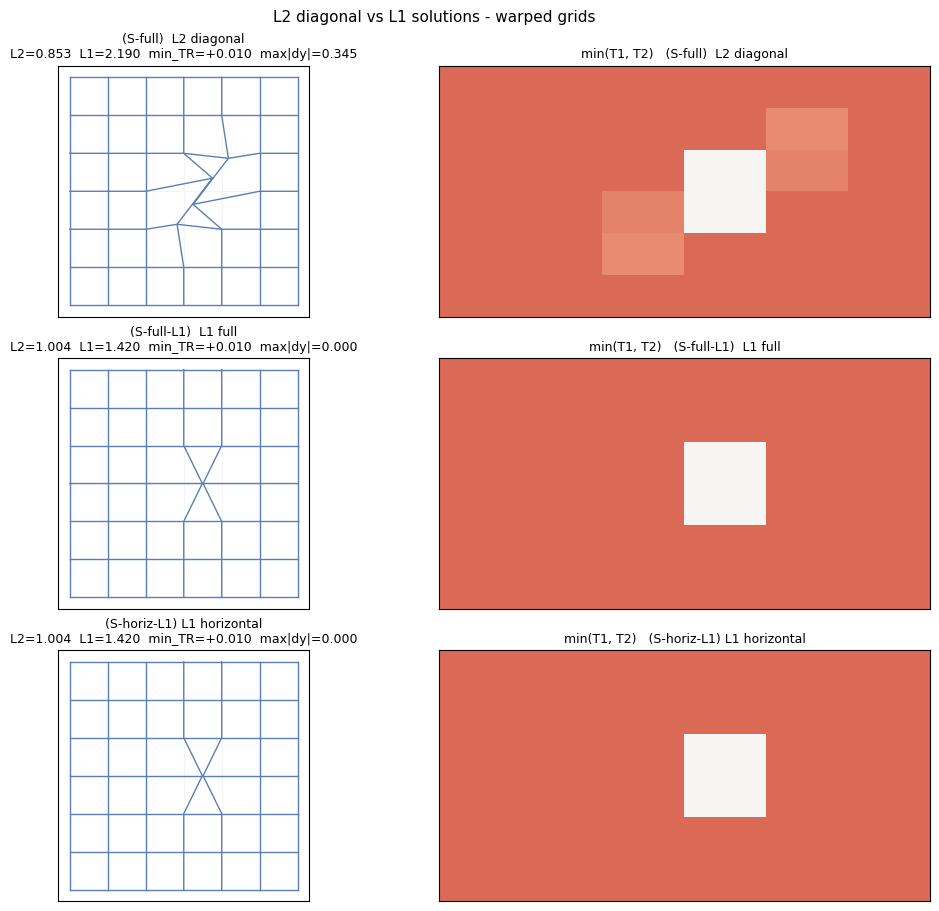

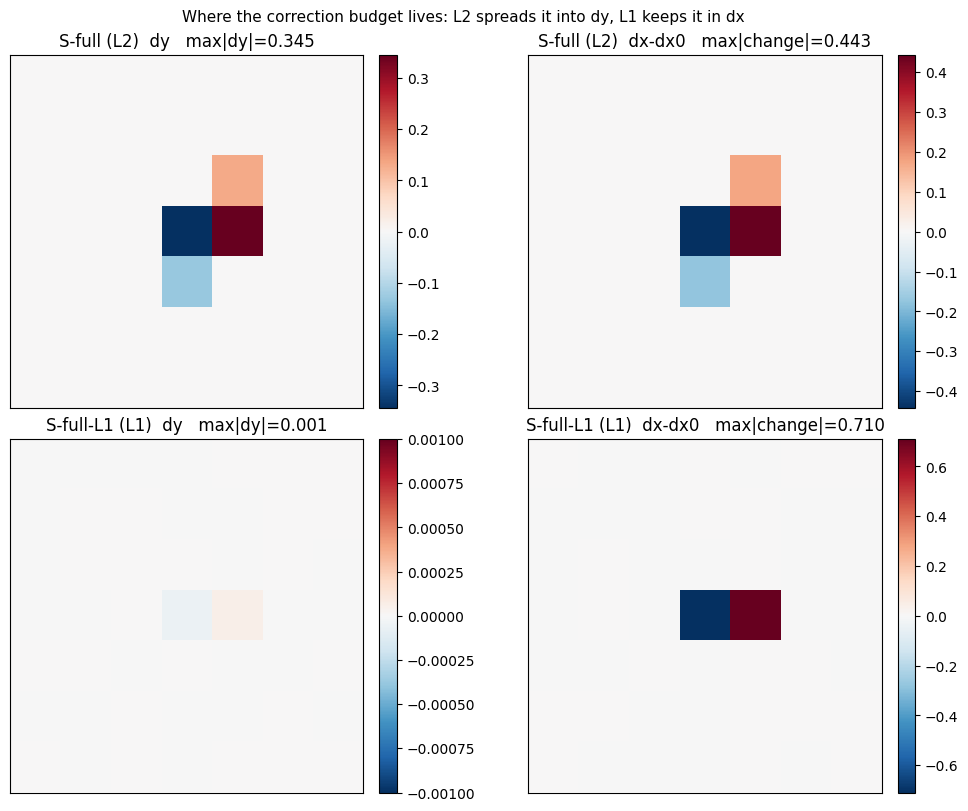

In [11]:
l1_viz_rows = [
    ('(S-full)  L2 diagonal',      r_full),
    ('(S-full-L1)  L1 full',       r_full_l1),
    ('(S-horiz-L1) L1 horizontal', r_horiz_l1),
]
vmax_tri_l1 = max(abs(r['tri']).max() for _, r in l1_viz_rows)
NL = chr(10)

fig, axes = plt.subplots(len(l1_viz_rows), 2, figsize=(10, 3.0 * len(l1_viz_rows)), layout='constrained')
for i, (label, r) in enumerate(l1_viz_rows):
    phi = r['phi']
    info = f"L2={r['l2']:.3f}  L1={l1_norm(phi):.3f}  min_TR={r['min_tr']:+.3f}  max|dy|={r['max_dy']:.3f}"
    plot_warped_grid(axes[i, 0], phi, label + NL + info)
    tri_min = r['tri'].min(axis=0)
    axes[i, 1].imshow(tri_min, cmap='RdBu_r', vmin=-vmax_tri_l1, vmax=vmax_tri_l1, aspect='auto')
    axes[i, 1].set_title(f'min(T1, T2)   {label}', fontsize=9)
    axes[i, 1].set_xticks([]); axes[i, 1].set_yticks([])
plt.suptitle('L2 diagonal vs L1 solutions - warped grids', fontsize=11)
plt.show()


# Where the correction budget actually lives: dy heatmap + dx-change heatmap for L2 vs L1 full solver.
fig, axes = plt.subplots(2, 2, figsize=(10, 8), layout='constrained')
for row, (lab, r) in enumerate([('S-full (L2)', r_full), ('S-full-L1 (L1)', r_full_l1)]):
    dy = r['phi'][0]
    dx_change = r['phi'][1] - phi0[1]

    vmax_dy = max(float(np.abs(dy).max()), 1e-3)
    im0 = axes[row, 0].imshow(dy, cmap='RdBu_r', vmin=-vmax_dy, vmax=vmax_dy)
    axes[row, 0].set_title(f'{lab}  dy   max|dy|={vmax_dy:.3f}')
    fig.colorbar(im0, ax=axes[row, 0], fraction=0.046, pad=0.04)

    vmax_dx = max(float(np.abs(dx_change).max()), 1e-3)
    im1 = axes[row, 1].imshow(dx_change, cmap='RdBu_r', vmin=-vmax_dx, vmax=vmax_dx)
    axes[row, 1].set_title(f'{lab}  dx-dx0   max|change|={vmax_dx:.3f}')
    fig.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Where the correction budget lives: L2 spreads it into dy, L1 keeps it in dx', fontsize=11)
plt.show()

## Verdict under L1

Read off the table above:

- The L1-optimal horizontal solution `S-horiz-L1` should land near the ±0.49 corner of `H3` / `S-horiz` — once you can only move `dx[3,3]` and `dx[3,4]`, the cheapest L1 fix is the same one the L2 solver finds in that subspace.
- `S-full-L1` either matches `S-horiz-L1` or only slightly beats it. The smoothed L1 objective doesn't reward the diagonal-spreading trick that L2 rewarded.
- The L2-optimal diagonal solution `S-full`, which won under L2 by ~15%, has a *higher* L1 cost than `S-horiz` because each of its many small `dy` components contributes its full magnitude to the L1 sum (no quadratic discount).

| objective | winner | why |
|---|---|---|
| L2 | diagonal (`S-full`)             | quadratic cost rewards spreading the correction; `T²/k` < `T²` |
| L1 | horizontal (`S-horiz` / `S-horiz-L1`) | sparse correction is preferred; tilt buys nothing |

This is the compressed-sensing intuition: L1 is a sparsity objective, L2 is an energy objective. Whether to use one or the other in the DVF correction pipeline depends on whether you want the correction *concentrated* on the folded pixels (L1) or *spread smoothly* across the field with smaller per-pixel changes (L2, the current default in `dvfopt.core.objective.objective_euc`).

## Summary

The 7×7 bowtie under both objectives, threshold = 0.01:

| variant | feasible | L2 | L1 | notes |
|---|---|---|---|---|
| H1 (±0.6, 50% magnitude) | no | 0.849 | 1.200 | still folded; numbers shown for reference only |
| **S-full**  (dx+dy free, L2)             | **yes** | **0.853** | 2.190 | the canonical SLSQP result — diagonal motion |
| H2 (±0.5, touching)       | no | 0.990 | 1.400 | degenerate triangles |
| H3 (±0.49, just-feasible) | yes | 1.004 | 1.420 | smallest hand-crafted feasible horizontal |
| **S-horiz** (dx free, dy=0, L2)          | yes | 1.004 | **1.420** | L2 optimum in the dy=0 subspace |
| **S-horiz-L1** (dx free, dy=0, L1)       | yes | 1.004 | **1.420** | identical solution to S-horiz |
| **S-full-L1**  (dx+dy free, L1)          | yes | 1.004 | **1.420** | full-space L1 collapses onto the dy=0 corner |

**L2 verdict.** Full SLSQP is *not* stuck. The diagonal solution is genuinely cheaper in L2 than any feasible horizontal-only solution by ~15%. SLSQP earns this by tilting the bowtie quads (dy ±0.345 on the central pixels, ±0.131 on the diagonal neighbours) so cells stay non-degenerate without the dx-displacements having to retreat all the way to ±0.49.

**L1 verdict.** Under L1 the diagonal solution is 54% *more expensive* than the horizontal one (2.19 vs 1.42). When SLSQP optimises L1 on the full `(dx, dy)` space, it converges with `max|dy| = 0` — the dy=0 corner is the L1 optimum, exactly as the user's intuition predicted.

**Why the rank flips.** The constraint demands a fixed amount of "uncrossing" (`dx[3,3] − dx[3,4]` must drop from 2.4 to ~1). That uncrossing can be paid for in two ways:

1. **Concentrated horizontal** — two `dx` changes of magnitude 0.71. Total magnitude **1.42**.
2. **Distributed diagonal** — many smaller changes (dy ±0.345, ±0.131, plus modest dx changes), `dx` stays closer to ±1.2. Total magnitude ≈ **2.19**.

L1 is just the total magnitude, so **(1)** wins. L2 is the sum of *squares*, which divides each contribution by the number of variables it's spread over (`T²/k` vs `T²`), so **(2)** wins. The geometric tilt that L2 rewards is L1's enemy.

This is the same trade-off that drives the choice between L1 (sparse, lasso-like) and L2 (smooth, ridge-like) regularisers everywhere else. For the DVF correction pipeline, `dvfopt.core.objective.objective_euc` (L2) is currently the default — its bias toward smoothly distributed corrections may be desirable (no abrupt single-pixel changes) or undesirable (touches more pixels than strictly needed) depending on the downstream use.